In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [2]:
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("viridis")

Cold Start

In [4]:
consumer_data = pd.read_csv("consumer_data.csv")
provider_data = pd.read_csv("provider_data.csv")
recommender_data = pd.read_csv("recommender_data.csv")

rename_map = {
    "mainstream_recommender_SurpriseSVD_0": "Mainstream",
    "niche_recommender_SurpriseSVD_1": "Niche"
}
# Filter valid recommender IDs for analyses
valid_recs = list(rename_map.keys())
recommender_filtered = recommender_data[recommender_data['recommender_id'].isin(valid_recs)].copy()
recommender_filtered['recommender_id'] = recommender_filtered['recommender_id'].map(rename_map)


## 1. Profit Comparison Across Cycles
Plots the average profit for the two recommender systems (mainstream and niche) over multiple cycles.  

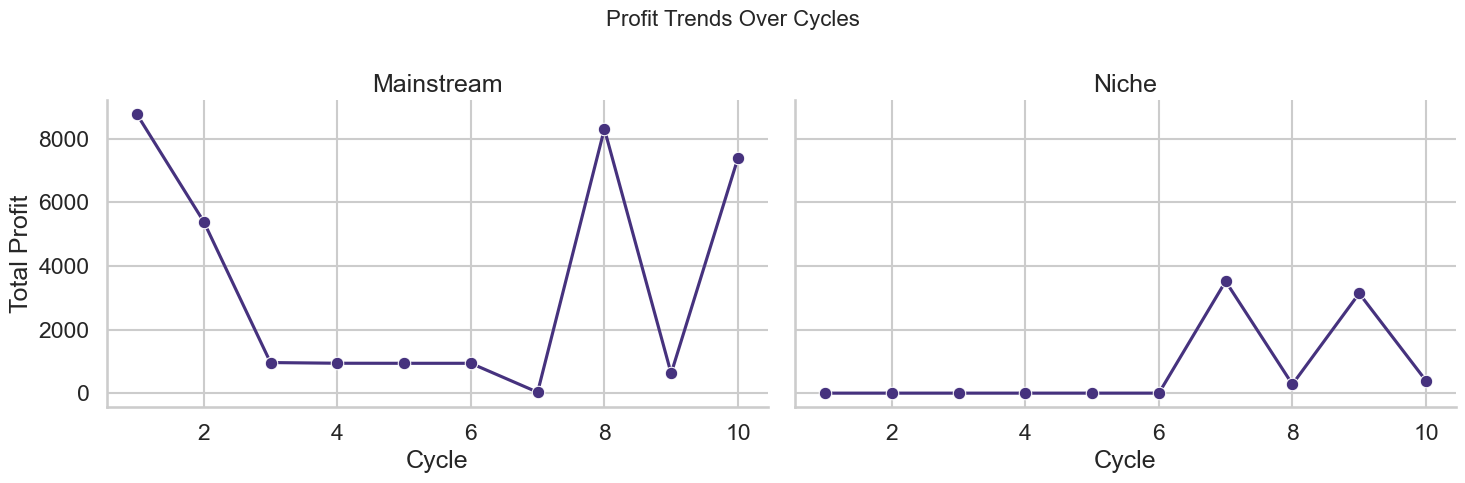

In [6]:
recommender_filtered = recommender_data[recommender_data['recommender_id'].isin(valid_recs)].copy()
recommender_filtered['recommender_id'] = recommender_filtered['recommender_id'].map(rename_map)

profit_by_cycle = recommender_filtered.groupby(['recommender_id', 'cycle'])['total_profit'].mean().reset_index()
g = sns.FacetGrid(profit_by_cycle, col="recommender_id", sharey=True, height=5, aspect=1.5)
g.map_dataframe(sns.lineplot, x="cycle", y="total_profit", marker="o", errorbar=('ci', 95))
g.set_axis_labels("Cycle", "Total Profit")
g.set_titles("{col_name}")
g.fig.suptitle("Profit Trends Over Cycles", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()

## 2. Stacked Bar Chart of Profits
Displays the cumulative profit per cycle, with each recommender's contribution stacked on top of the other.  

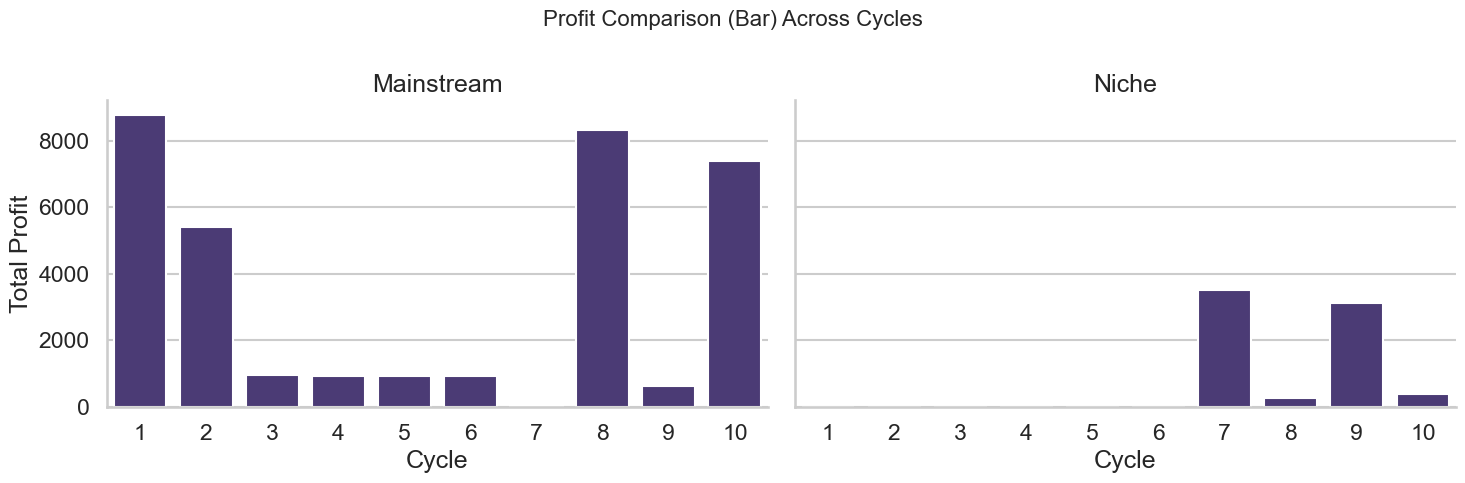

In [8]:
g = sns.FacetGrid(profit_by_cycle, col="recommender_id", sharey=True, height=5, aspect=1.5)
g.map_dataframe(sns.barplot, x="cycle", y="total_profit", dodge=False)
g.set_axis_labels("Cycle", "Total Profit")
g.set_titles("{col_name}")
g.fig.suptitle("Profit Comparison (Bar) Across Cycles", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()


## 3. Switching Percentage per Cycle 
Shows the percentage of consumers switching recommender systems (based on low satisfaction scores) from one cycle to the next.  

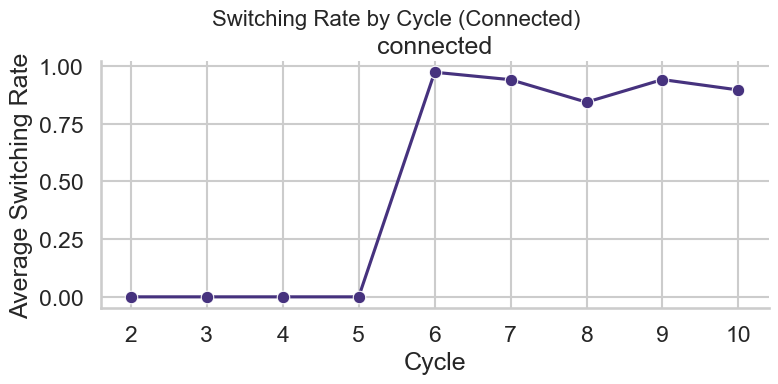

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("consumer_data.csv")

# Only the row where rec_state ==connected
df_connected = df[df['rec_state'] == 'connected'].copy()
df_connected.sort_values(['consumer_id', 'cycle'], inplace=True)
df_connected['prev_recommender_id'] = df_connected.groupby('consumer_id')['recommender_id'].shift(1)

# drop rows where there is no prev recommender
df_connected = df_connected.dropna(subset=['prev_recommender_id'])

# flagging a switch 
df_connected['switch'] = (df_connected['recommender_id'] != df_connected['prev_recommender_id']).astype(int)

# group by cycle and calculate mean switching rate
switching_by_cycle = df_connected.groupby('cycle')['switch'].mean().reset_index()

switching_by_cycle['rec_state'] = 'connected'

g = sns.FacetGrid(
    switching_by_cycle,
    col='rec_state',      
    sharex=True,
    sharey=True,
    height=4,
    aspect=2
)
g.map(sns.lineplot, 'cycle', 'switch', marker='o')

g.set_axis_labels("Cycle", "Average Switching Rate")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Switching Rate by Cycle (Connected)", fontsize=16)
plt.show()


## 4. Consumer Satisfaction Distribution per Cycle
Consumer satisfaction scores across cycles, considering only active (connected) consumers.  

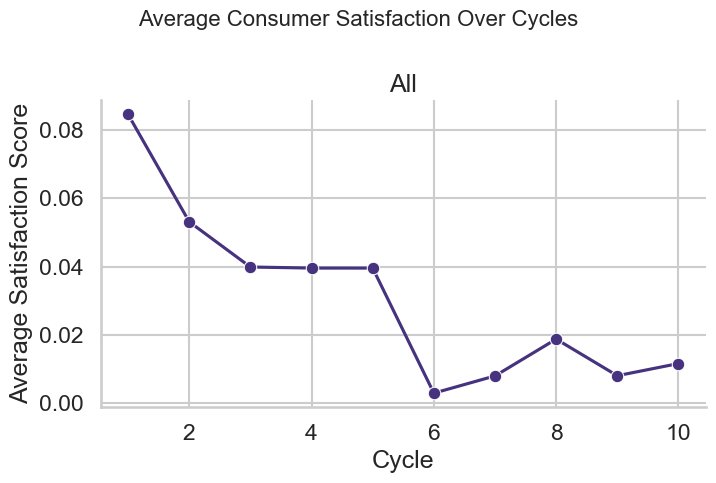

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Filter only the rows where the consumer is actually connected
consumer_connected = df[df['rec_state'] == 'connected'].copy()

# 2) Calculate average satisfaction score by cycle
avg_sat = consumer_connected.groupby('cycle')['satisfaction_score'].mean().reset_index()
avg_sat["All"] = "All"

# 3) Create the FacetGrid for visualization
g = sns.FacetGrid(avg_sat, col="All", sharey=True, height=5, aspect=1.5)
g.map_dataframe(
    sns.lineplot,
    x="cycle",
    y="satisfaction_score",
    marker="o",
    errorbar=('ci', 95)
)
g.set_axis_labels("Cycle", "Average Satisfaction Score")
g.set_titles("{col_name}")
g.fig.suptitle("Average Consumer Satisfaction Over Cycles", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()


## 5. Provider Profit Distribution 
Compares the distribution of profit for providers between the two recommender systems, focusing on cases where profit is nonzero (or using a log scale if appropriate).  

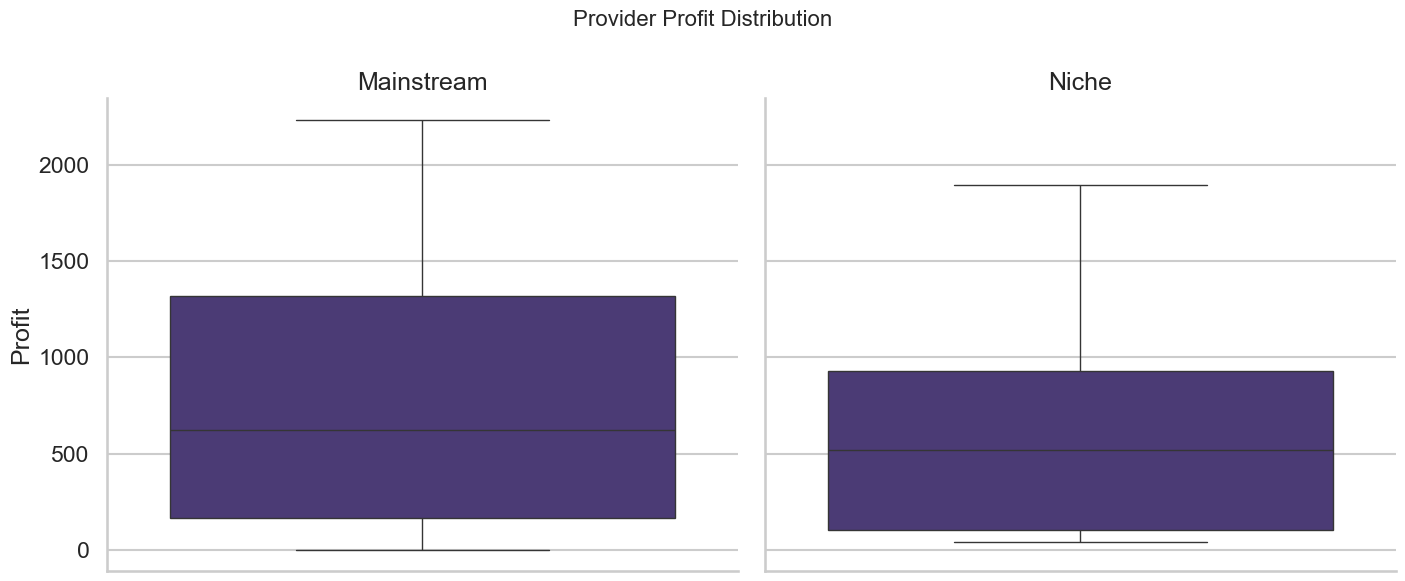

In [14]:
provider_nonzero = provider_data[provider_data['profit'] > 0]
Q1 = provider_nonzero['profit'].quantile(0.25)
Q3 = provider_nonzero['profit'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
provider_filtered = provider_nonzero[provider_nonzero['profit'] <= upper_bound].copy()
provider_filtered['recommender_id'] = provider_filtered['recommender_id'].map(rename_map)

g = sns.FacetGrid(provider_filtered, col="recommender_id", sharey=True, height=6, aspect=1.2)
g.map_dataframe(sns.boxplot, y="profit")
g.set_axis_labels("", "Profit")
g.set_titles("{col_name}")
g.fig.suptitle("Provider Profit Distribution", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()

## 6. User Satisfaction Distribution
Compares user satisfaction scores between the recommender systems. By filtering out zero scores and removing outliers, it provides a clear, focused view of the typical satisfaction levels for each system..  

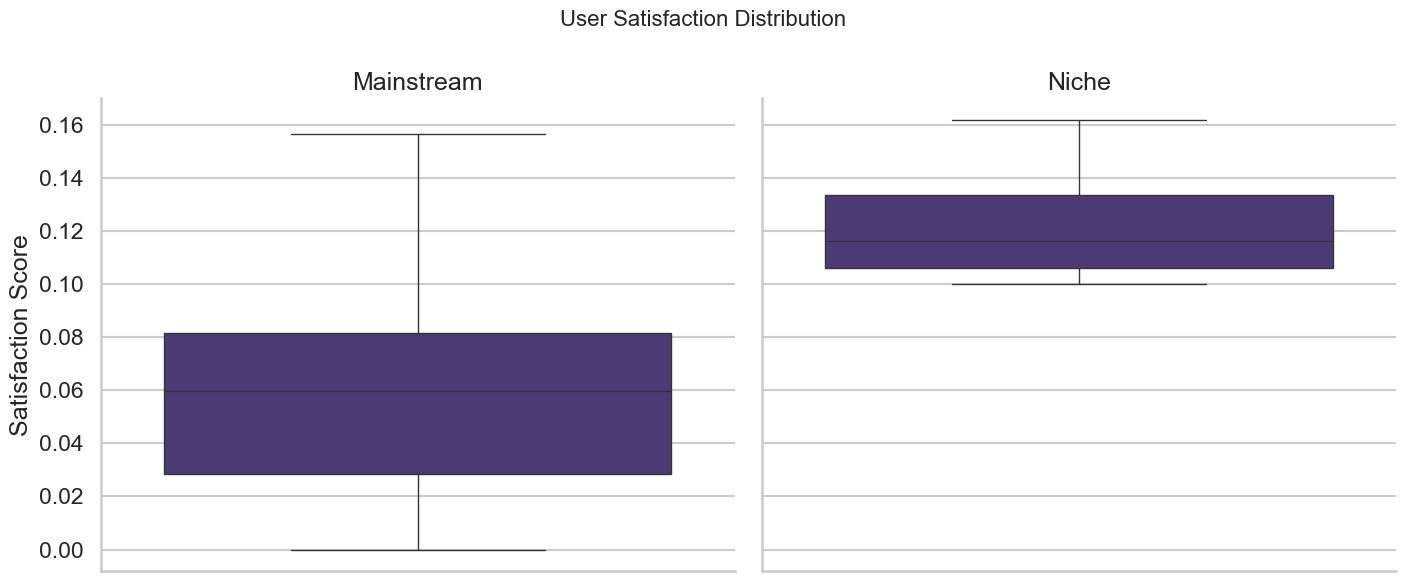

In [16]:
consumer_nonzero = consumer_data[consumer_data['satisfaction_score'] > 0]
Q1 = consumer_nonzero['satisfaction_score'].quantile(0.25)
Q3 = consumer_nonzero['satisfaction_score'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
consumer_filtered = consumer_nonzero[consumer_nonzero['satisfaction_score'] <= upper_bound].copy()
consumer_filtered['recommender_id'] = consumer_filtered['recommender_id'].map(rename_map)

g = sns.FacetGrid(consumer_filtered, col="recommender_id", sharey=True, height=6, aspect=1.2)
g.map_dataframe(sns.boxplot, y="satisfaction_score")
g.set_axis_labels("", "Satisfaction Score")
g.set_titles("{col_name}")
g.fig.suptitle("User Satisfaction Distribution", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()


## 7. Average User Satisfaction Trend
Average user satisfaction evolves over time across cycles for each recommender system. It highlights trends in user engagement, showing whether satisfaction improves or declines with each cycle.

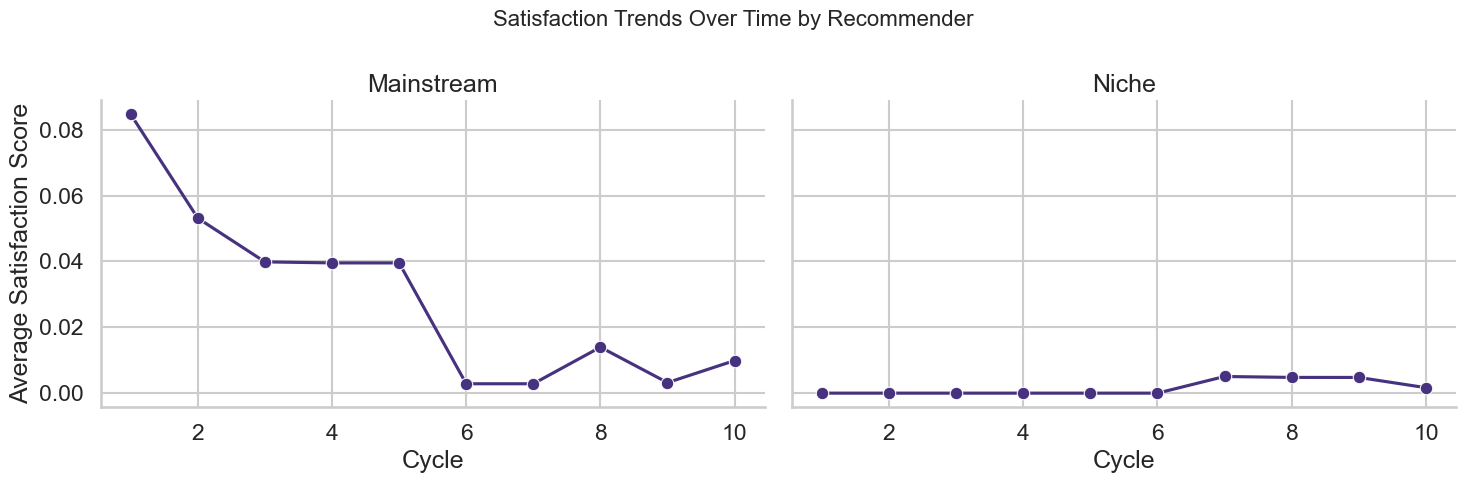

In [18]:
avg_satisfaction = consumer_data.groupby(["cycle", "recommender_id"])["satisfaction_score"].mean().reset_index()
avg_satisfaction['recommender_id'] = avg_satisfaction['recommender_id'].map(rename_map)

g = sns.FacetGrid(avg_satisfaction, col="recommender_id", sharey=True, height=5, aspect=1.5)
g.map_dataframe(sns.lineplot, x="cycle", y="satisfaction_score", marker="o", errorbar=('ci', 95))
g.set_axis_labels("Cycle", "Average Satisfaction Score")
g.set_titles("{col_name}")
g.fig.suptitle("Satisfaction Trends Over Time by Recommender", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Load your data from consumer_data.csv
df = pd.read_csv("consumer_data.csv")

# Filter to only include rows where the consumer is connected
df_connected = df[df['rec_state'] == 'connected'].copy()

# Sort by consumer_id and cycle to ensure chronological order
df_connected.sort_values(['consumer_id', 'cycle'], inplace=True)

# For a specific consumer, for example, consumer_id 4698
consumer_id = 4698
df_consumer = df_connected[df_connected['consumer_id'] == consumer_id].copy()

# Create a column for the previous cycle's connected recommender_id for this consumer
df_consumer['prev_recommender_id'] = df_consumer['recommender_id'].shift(1)

# Flag a switch when the current recommender is different from the previous one
df_consumer['switch'] = (df_consumer['recommender_id'] != df_consumer['prev_recommender_id']).astype(int)

# Count the number of switches (exclude the first cycle since it has no previous record)
num_switches = df_consumer['switch'].iloc[1:].sum()

print(f"Consumer {consumer_id} switched {num_switches} times across cycles.")

# Show detailed switching and satisfaction information per cycle
print(df_consumer[['cycle', 'recommender_id', 'prev_recommender_id', 'switch', 'satisfaction_score']])


Consumer 4698 switched 4 times across cycles.
        cycle                        recommender_id  \
2886        1  mainstream_recommender_SurpriseSVD_0   
14966       2  mainstream_recommender_SurpriseSVD_0   
27046       3  mainstream_recommender_SurpriseSVD_0   
39126       4  mainstream_recommender_SurpriseSVD_0   
51206       5  mainstream_recommender_SurpriseSVD_0   
63287       6       niche_recommender_SurpriseSVD_1   
75366       7  mainstream_recommender_SurpriseSVD_0   
87446       8  mainstream_recommender_SurpriseSVD_0   
99527       9       niche_recommender_SurpriseSVD_1   
111606     10  mainstream_recommender_SurpriseSVD_0   

                         prev_recommender_id  switch  satisfaction_score  
2886                                    None       1        9.824362e-02  
14966   mainstream_recommender_SurpriseSVD_0       0        2.495950e-02  
27046   mainstream_recommender_SurpriseSVD_0       0        4.328359e-04  
39126   mainstream_recommender_SurpriseSVD_0    

In [20]:
import pandas as pd

# Load your dataset (adjust the file path as needed)
df = pd.read_csv("consumer_data.csv")

# Filter to include only rows where the consumer is connected
df_connected = df[df['rec_state'] == 'connected'].copy()

# Sort by consumer_id and cycle to ensure chronological order
df_connected.sort_values(['consumer_id', 'cycle'], inplace=True)

# Specify the consumer you want to track (e.g., consumer_id 4698)
consumer_id = 4698
df_consumer = df_connected[df_connected['consumer_id'] == consumer_id].copy()

# Create a column for the previous cycle's connected recommender_id
df_consumer['prev_recommender_id'] = df_consumer['recommender_id'].shift(1)

# Create a flag to indicate whether a switch occurred
df_consumer['switched'] = (df_consumer['recommender_id'] != df_consumer['prev_recommender_id'])

# Display the tracking information
print(df_consumer[['cycle', 'recommender_id', 'prev_recommender_id', 'satisfaction_score', 'switched']])


        cycle                        recommender_id  \
2886        1  mainstream_recommender_SurpriseSVD_0   
14966       2  mainstream_recommender_SurpriseSVD_0   
27046       3  mainstream_recommender_SurpriseSVD_0   
39126       4  mainstream_recommender_SurpriseSVD_0   
51206       5  mainstream_recommender_SurpriseSVD_0   
63287       6       niche_recommender_SurpriseSVD_1   
75366       7  mainstream_recommender_SurpriseSVD_0   
87446       8  mainstream_recommender_SurpriseSVD_0   
99527       9       niche_recommender_SurpriseSVD_1   
111606     10  mainstream_recommender_SurpriseSVD_0   

                         prev_recommender_id  satisfaction_score  switched  
2886                                    None        9.824362e-02      True  
14966   mainstream_recommender_SurpriseSVD_0        2.495950e-02     False  
27046   mainstream_recommender_SurpriseSVD_0        4.328359e-04     False  
39126   mainstream_recommender_SurpriseSVD_0        7.506036e-06     False  
51206   m

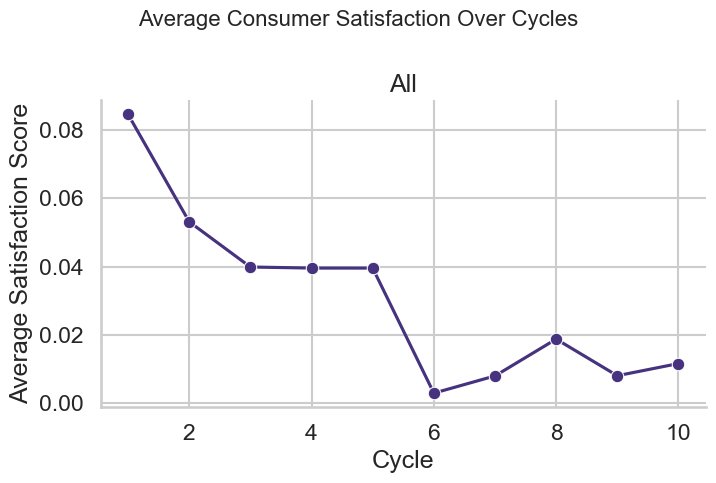

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data (adjust the file path as needed)
df = pd.read_csv("consumer_data.csv")

# Filter to include only rows where the consumer is connected
consumer_connected = df[df['rec_state'] == 'connected'].copy()

# Ensure data is sorted by cycle (and optionally by consumer_id)
consumer_connected.sort_values(['consumer_id', 'cycle'], inplace=True)

# Group by cycle and calculate the mean satisfaction score
avg_sat = consumer_connected.groupby('cycle')['satisfaction_score'].mean().reset_index()
avg_sat["All"] = "All"

# Set up a FacetGrid to plot the average satisfaction over cycles
g = sns.FacetGrid(avg_sat, col="All", sharey=True, height=5, aspect=1.5)
g.map_dataframe(sns.lineplot, x="cycle", y="satisfaction_score", marker="o", errorbar=('ci', 95))
g.set_axis_labels("Cycle", "Average Satisfaction Score")
g.set_titles("{col_name}")
g.fig.suptitle("Average Consumer Satisfaction Over Cycles", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()


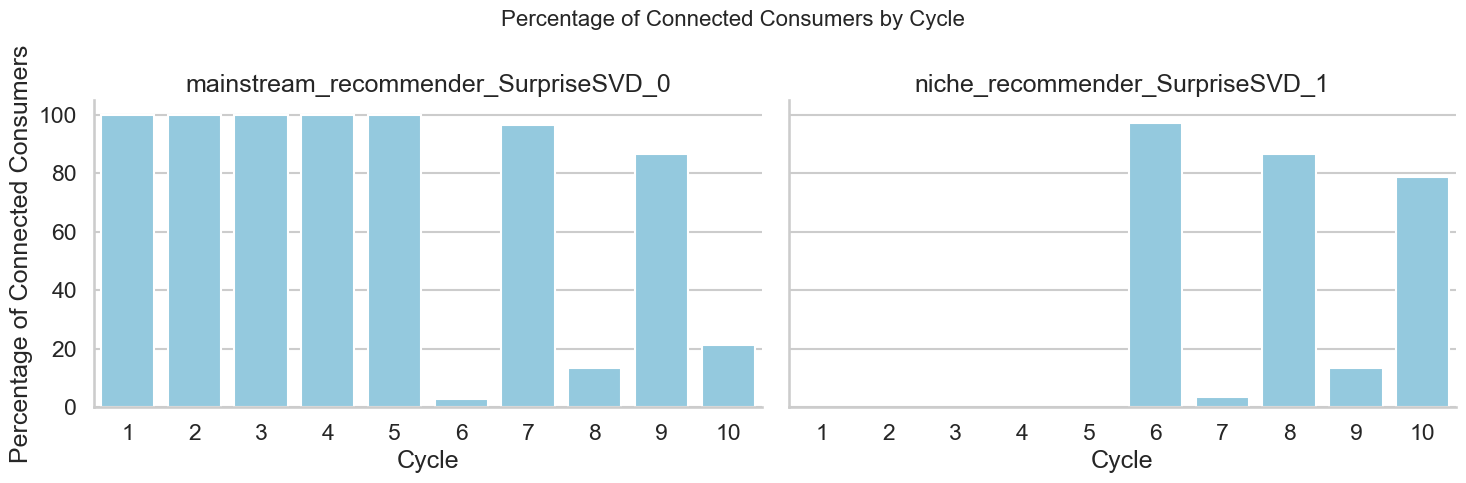

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("consumer_data.csv")

# Filter for connected consumers
df_connected = df[df['rec_state'] == 'connected'].copy()

# Focus on the two recommender_ids of interest
recommender_ids = [
    'mainstream_recommender_SurpriseSVD_0',
    'niche_recommender_SurpriseSVD_1'
]
df_connected = df_connected[df_connected['recommender_id'].isin(recommender_ids)]

# Group by cycle and recommender_id to count the number of connected consumers per cycle
counts = df_connected.groupby(['cycle', 'recommender_id']).size().reset_index(name='count')

# Compute total connected consumers per cycle (for these two recommender_ids)
total_counts = df_connected.groupby('cycle').size().reset_index(name='total')

# Merge counts with total counts and calculate percentage
percentage_by_cycle = pd.merge(counts, total_counts, on='cycle')
percentage_by_cycle['percentage'] = percentage_by_cycle['count'] / percentage_by_cycle['total'] * 100

# Create a bar chart for each recommender using FacetGrid
g = sns.FacetGrid(percentage_by_cycle, col="recommender_id", sharey=True, height=5, aspect=1.5)
g.map_dataframe(sns.barplot, x="cycle", y="percentage", color='skyblue', dodge=False)
g.set_axis_labels("Cycle", "Percentage of Connected Consumers")
g.set_titles("{col_name}")
g.fig.suptitle("Percentage of Connected Consumers by Cycle", fontsize=16)
plt.subplots_adjust(top=0.85)
sns.despine()
plt.tight_layout()
plt.show()
